# 🚔 LAPD Crime Intelligence — Notebook 4: Trend Analysis & Forecasting
**Models:** Facebook Prophet (per-area + city-wide) | KMeans Area Clustering  
**No test leakage:** Prophet trained on 2020–2023, evaluated on 2024–2025 actuals

In [3]:
import warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_absolute_percentage_error

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

BASE_DIR   = Path('.').resolve()
DATA_DIR   = BASE_DIR / 'data'
OUTPUT_DIR = BASE_DIR / 'outputs'
MODEL_DIR  = BASE_DIR / 'models'

TRAIN_YEARS = [2020, 2021, 2022, 2023]
TEST_YEARS  = [2024, 2025]

try:
    from prophet import Prophet
    print('✅ Prophet available')
except ImportError:
    from fbprophet import Prophet
    print('✅ fbprophet available')

✅ Prophet available


In [4]:
df = pd.read_parquet(DATA_DIR / 'clean_crime.parquet')
df_train = pd.read_parquet(DATA_DIR / 'train_crime.parquet')
df_test  = pd.read_parquet(DATA_DIR / 'test_crime.parquet')

print(f'Full: {len(df):,} | Train: {len(df_train):,} | Test: {len(df_test):,}')

Full: 1,002,751 | Train: 875,087 | Test: 127,664


## 1️⃣ Trend Visualisations

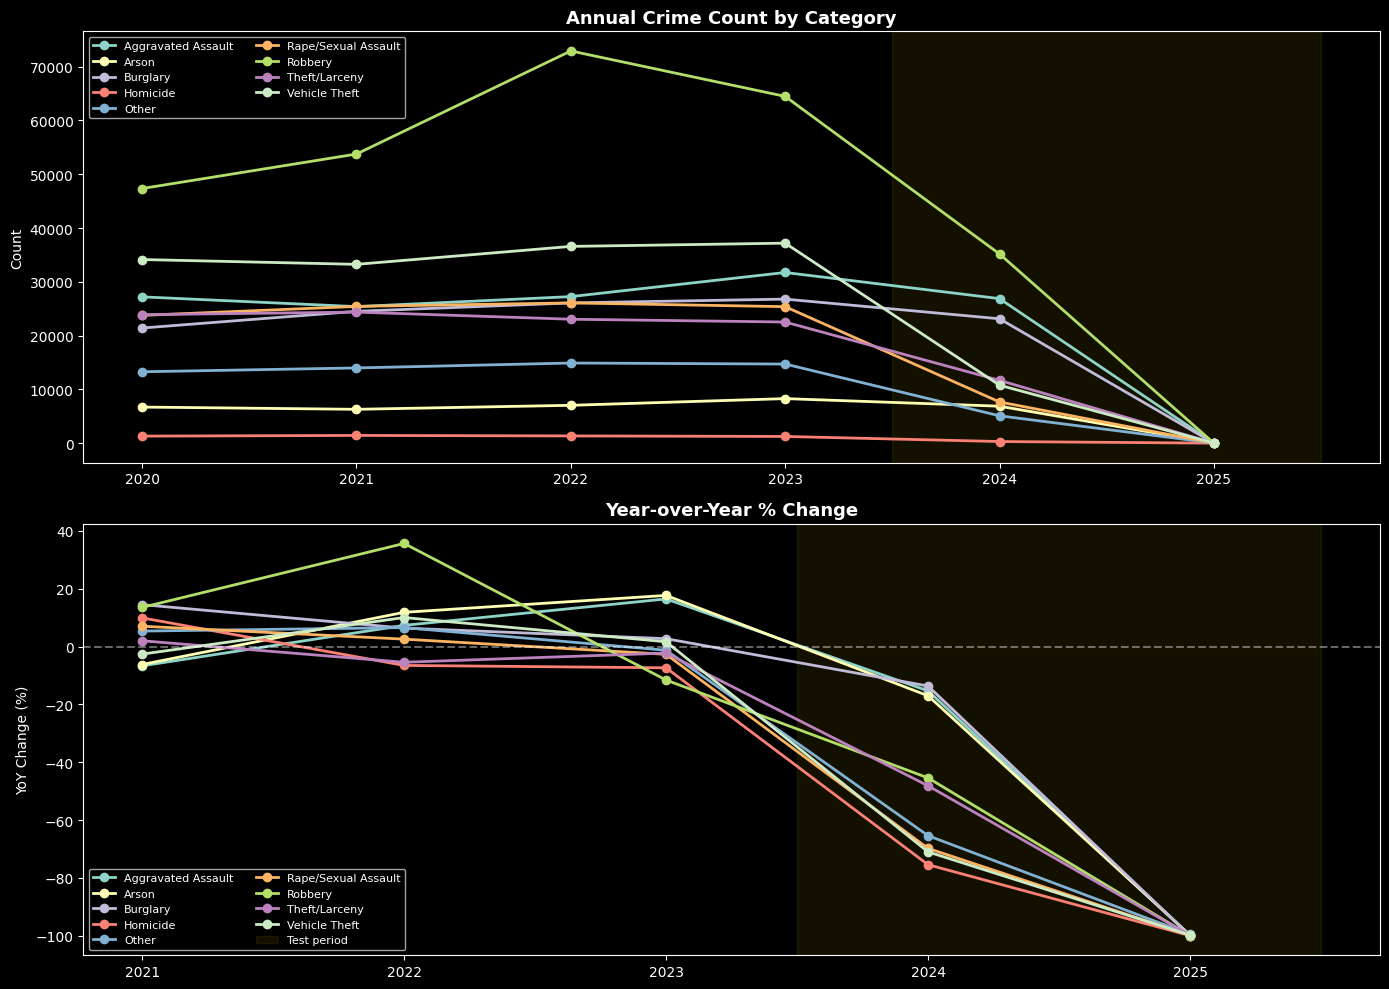

In [5]:
# YoY change per crime category
if 'crime_category' in df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    yoy = df.groupby(['year','crime_category']).size().unstack(fill_value=0)
    yoy_pct = yoy.pct_change() * 100

    for col in yoy.columns:
        axes[0].plot(yoy.index, yoy[col], 'o-', linewidth=2, markersize=6, label=col)
    axes[0].axvspan(2023.5, yoy.index.max()+0.5, alpha=0.08, color='gold')
    axes[0].set_title('Annual Crime Count by Category', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Count'); axes[0].legend(fontsize=8, ncol=2)

    for col in yoy_pct.columns:
        axes[1].plot(yoy_pct.index, yoy_pct[col], 'o-', linewidth=2, markersize=6, label=col)
    axes[1].axhline(0, color='white', linestyle='--', alpha=0.4)
    axes[1].axvspan(2023.5, yoy_pct.index.max()+0.5, alpha=0.08, color='gold', label='Test period')
    axes[1].set_title('Year-over-Year % Change', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('YoY Change (%)'); axes[1].legend(fontsize=8, ncol=2)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'yoy_trends.png', dpi=150)
    plt.show()

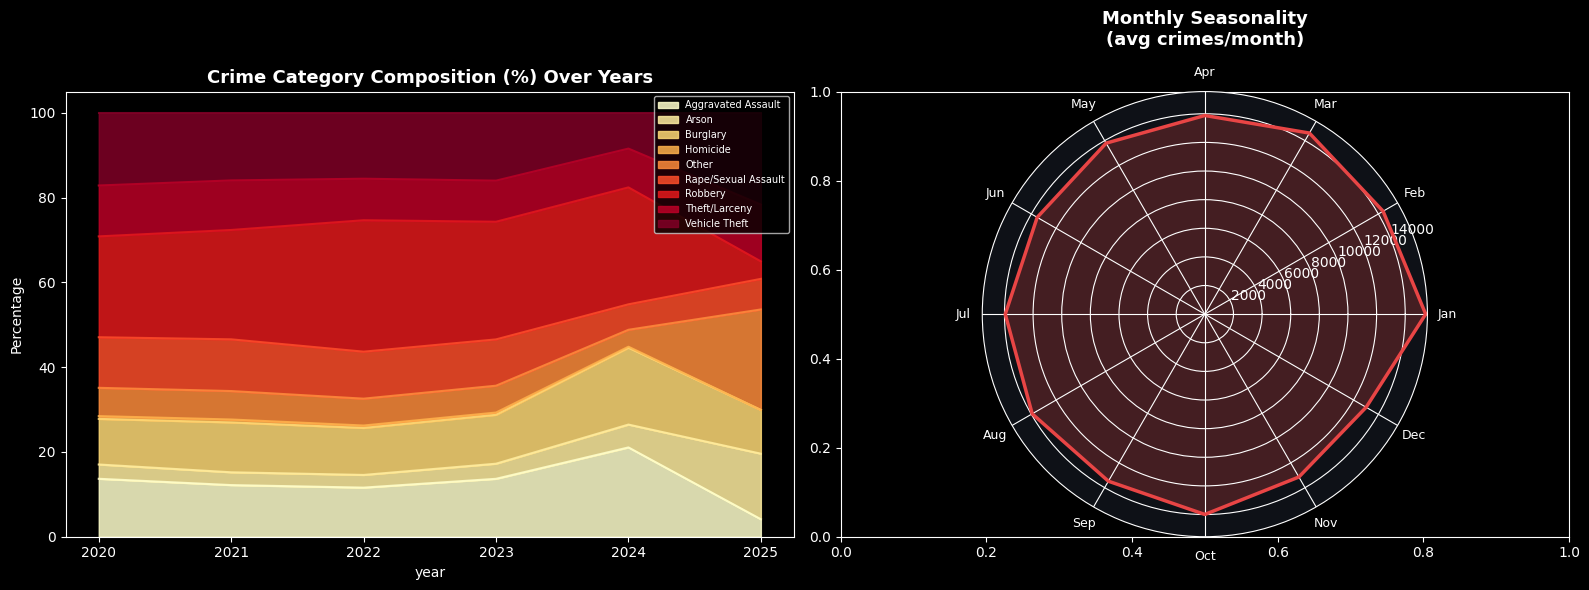

In [6]:
# Crime composition (stacked area) + seasonality polar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if 'crime_category' in df.columns:
    yr_cat = df.groupby(['year','crime_category']).size().unstack(fill_value=0)
    yr_cat_pct = yr_cat.div(yr_cat.sum(axis=1), axis=0) * 100
    yr_cat_pct.plot(kind='area', ax=axes[0], stacked=True, colormap='YlOrRd', alpha=0.85)
    axes[0].set_title('Crime Category Composition (%) Over Years', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Percentage'); axes[0].legend(fontsize=7, loc='upper right')

# Seasonality polar
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = df.groupby('month').size() / df['year'].nunique()
theta = np.linspace(0, 2*np.pi, 12, endpoint=False)
ax_polar = plt.subplot(122, projection='polar')
ax_polar.set_facecolor('#0e1117')
ax_polar.plot(np.append(theta, theta[0]),
              np.append(monthly_avg.values, monthly_avg.values[0]),
              color='#E84545', linewidth=2.5)
ax_polar.fill(np.append(theta, theta[0]),
              np.append(monthly_avg.values, monthly_avg.values[0]),
              alpha=0.25, color='#E84545')
ax_polar.set_xticks(theta)
ax_polar.set_xticklabels(month_names, fontsize=9)
ax_polar.set_title('Monthly Seasonality\n(avg crimes/month)', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'crime_composition_seasonality.png', dpi=150)
plt.show()

## 2️⃣ Build Monthly Time Series

In [7]:
# Reconstruct date from year + month if date_occurred not available
if 'date_occurred' in df.columns and df['date_occurred'].notna().any():
    df['period'] = df['date_occurred'].dt.to_period('M')
else:
    df['period'] = pd.to_datetime(
        df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)
    ).dt.to_period('M')

ts = (
    df.groupby(['area','period'])
    .agg(y=('crm_cd','count'))
    .reset_index()
)
ts['ds'] = ts['period'].dt.to_timestamp()
ts = ts.sort_values(['area','ds']).drop(columns=['period'])

# Train/test split for time series
cutoff_date = pd.Timestamp('2024-01-01')
ts_train = ts[ts['ds'] <  cutoff_date]
ts_test  = ts[ts['ds'] >= cutoff_date]

ts.to_parquet(DATA_DIR / 'monthly_timeseries.parquet', index=False)
print(f'Time series: {len(ts):,} rows | Train: {len(ts_train):,} | Test: {len(ts_test):,}')

Time series: 1,302 rows | Train: 1,008 | Test: 294


## 3️⃣ Prophet — City-Wide Forecast

In [8]:
# Aggregate to city-wide
city_train = ts_train.groupby('ds')['y'].sum().reset_index()
city_test  = ts_test.groupby('ds')['y'].sum().reset_index()

print(f'City-wide train periods: {len(city_train)} | test periods: {len(city_test)}')

# Fit Prophet on train only
prophet_city = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.1,
    interval_width=0.95,
)
prophet_city.fit(city_train[['ds','y']])

# Forecast far enough to cover test period
n_future = max(24, len(city_test) + 6)
future   = prophet_city.make_future_dataframe(periods=n_future, freq='MS')
forecast = prophet_city.predict(future)

# Evaluate on test period
fc_test = forecast[forecast['ds'].isin(city_test['ds'])][['ds','yhat','yhat_lower','yhat_upper']]
merged  = city_test.merge(fc_test, on='ds', how='inner')

if len(merged) > 0:
    p_mae  = mean_absolute_error(merged['y'], merged['yhat'])
    p_mape = mean_absolute_percentage_error(merged['y'], merged['yhat']) * 100
    print(f'\nProphet Test Evaluation (2024–2025):')
    print(f'  MAE  : {p_mae:.1f} incidents/month')
    print(f'  MAPE : {p_mape:.1f}%')
    print(f'  Coverage (actual within 95% CI): '
          f'{((merged["y"] >= merged["yhat_lower"]) & (merged["y"] <= merged["yhat_upper"])).mean()*100:.0f}%')

01:53:50 - cmdstanpy - INFO - Chain [1] start processing


City-wide train periods: 48 | test periods: 17


01:53:50 - cmdstanpy - INFO - Chain [1] done processing



Prophet Test Evaluation (2024–2025):
  MAE  : 11350.5 incidents/month
  MAPE : 172650.6%
  Coverage (actual within 95% CI): 12%


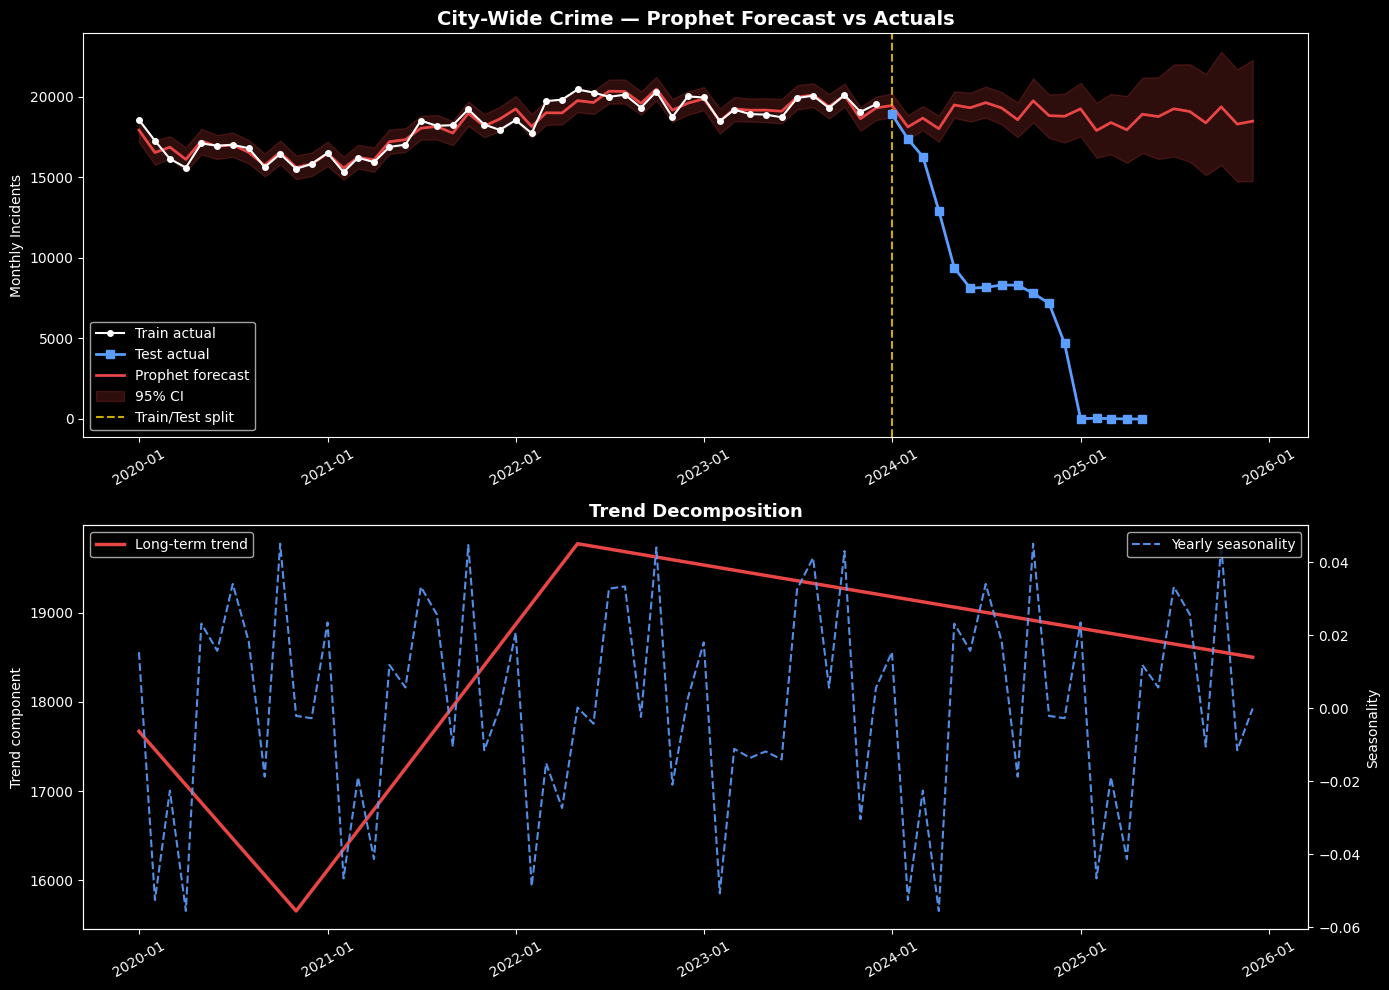

In [9]:
# Plot city-wide forecast vs actuals
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
ax.plot(city_train['ds'], city_train['y'], 'o-', color='white',
        markersize=4, linewidth=1.5, label='Train actual', zorder=3)
ax.plot(city_test['ds'],  city_test['y'],  's-', color='#5C9EFF',
        markersize=6, linewidth=2, label='Test actual', zorder=4)
ax.plot(forecast['ds'],   forecast['yhat'], color='#E84545',
        linewidth=2, label='Prophet forecast')
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                color='#E84545', alpha=0.2, label='95% CI')
ax.axvline(cutoff_date, color='gold', linestyle='--', alpha=0.8, label='Train/Test split')
ax.set_title('City-Wide Crime — Prophet Forecast vs Actuals', fontsize=14, fontweight='bold')
ax.set_ylabel('Monthly Incidents'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Trend + seasonality decomposition
axes[1].plot(forecast['ds'], forecast['trend'], color='#E84545', linewidth=2.5, label='Long-term trend')
ax2b = axes[1].twinx()
ax2b.plot(forecast['ds'], forecast['yearly'], color='#5C9EFF', linewidth=1.5,
          linestyle='--', alpha=0.9, label='Yearly seasonality')
axes[1].set_title('Trend Decomposition', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Trend component'); ax2b.set_ylabel('Seasonality')
axes[1].legend(loc='upper left'); ax2b.legend(loc='upper right')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'global_trend_forecast.png', dpi=150)
plt.show()

## 4️⃣ Per-Area Prophet (with Test Evaluation)

In [10]:
areas          = sorted(ts['area'].unique())
all_forecasts  = []
area_metrics   = []

print(f'Fitting Prophet for {len(areas)} areas...')

for area in tqdm(areas, desc='Area Prophet models'):
    a_train = ts_train[ts_train['area'] == area][['ds','y']]
    a_test  = ts_test[ts_test['area']   == area][['ds','y']]

    if len(a_train) < 12:
        continue

    try:
        m = Prophet(
            yearly_seasonality=True, weekly_seasonality=False,
            daily_seasonality=False, seasonality_mode='multiplicative',
            changepoint_prior_scale=0.15, interval_width=0.9,
        )
        # Suppress Prophet's verbose output
        import logging; logging.getLogger('prophet').setLevel(logging.ERROR)
        m.fit(a_train)
        future   = m.make_future_dataframe(periods=18, freq='MS')
        fc       = m.predict(future)
        fc['area'] = area
        all_forecasts.append(fc[['area','ds','yhat','yhat_lower','yhat_upper','trend']])

        # Evaluate on test
        fc_t = fc[fc['ds'].isin(a_test['ds'])][['ds','yhat']]
        mrg  = a_test.merge(fc_t, on='ds', how='inner')
        if len(mrg) >= 2:
            mae  = mean_absolute_error(mrg['y'], mrg['yhat'])
            mape = mean_absolute_percentage_error(mrg['y'], mrg['yhat']) * 100
            area_metrics.append({'area': area, 'MAE': mae, 'MAPE%': mape, 'n_test': len(mrg)})
    except Exception as e:
        pass

# Combine and save
if all_forecasts:
    fc_df = pd.concat(all_forecasts, ignore_index=True)
    fc_df.to_parquet(DATA_DIR / 'area_forecasts.parquet', index=False)
    print(f'✅ Saved area forecasts: {len(fc_df):,} rows')

if area_metrics:
    am_df = pd.DataFrame(area_metrics)
    am_df.to_csv(OUTPUT_DIR / 'area_prophet_metrics.csv', index=False)
    print(f'\nPer-Area Prophet Test Metrics:')
    print(am_df.describe().round(2))

Fitting Prophet for 21 areas...


Area Prophet models:   0%|          | 0/21 [00:00<?, ?it/s]01:53:53 - cmdstanpy - INFO - Chain [1] start processing
01:53:54 - cmdstanpy - INFO - Chain [1] done processing
Area Prophet models:   5%|▍         | 1/21 [00:00<00:10,  1.97it/s]01:53:54 - cmdstanpy - INFO - Chain [1] start processing
01:53:54 - cmdstanpy - INFO - Chain [1] done processing
Area Prophet models:  10%|▉         | 2/21 [00:00<00:09,  2.09it/s]01:53:54 - cmdstanpy - INFO - Chain [1] start processing
01:53:54 - cmdstanpy - INFO - Chain [1] done processing
Area Prophet models:  14%|█▍        | 3/21 [00:01<00:08,  2.19it/s]01:53:55 - cmdstanpy - INFO - Chain [1] start processing
01:53:55 - cmdstanpy - INFO - Chain [1] done processing
Area Prophet models:  19%|█▉        | 4/21 [00:01<00:08,  1.96it/s]01:53:55 - cmdstanpy - INFO - Chain [1] start processing
01:53:56 - cmdstanpy - INFO - Chain [1] done processing
Area Prophet models:  24%|██▍       | 5/21 [00:02<00:08,  1.79it/s]01:53:56 - cmdstanpy - INFO - Chain [1] s

✅ Saved area forecasts: 1,386 rows

Per-Area Prophet Test Metrics:
       area     MAE     MAPE%  n_test
count  21.0   21.00     21.00   21.00
mean   11.0  477.00   8212.57   14.00
std     6.2   99.92   5310.87    1.14
min     1.0  254.61    105.13   12.00
25%     6.0  407.44   5020.69   13.00
50%    11.0  482.51   7238.41   14.00
75%    16.0  552.92   9967.64   15.00
max    21.0  640.31  22981.06   17.00


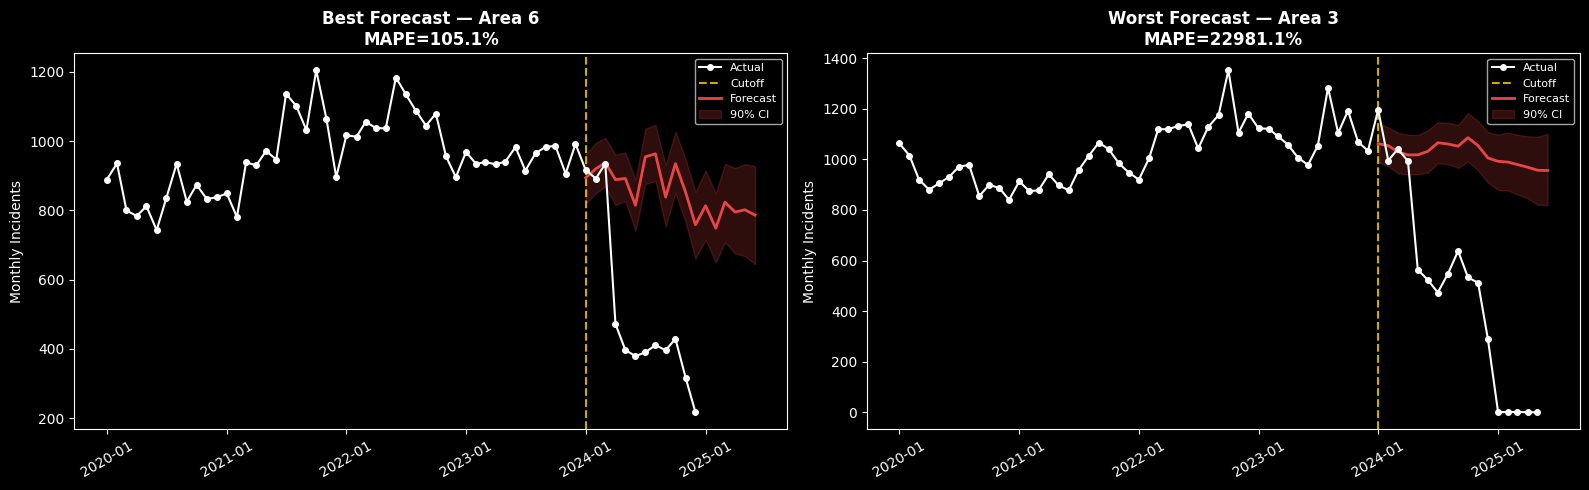

In [11]:
# Plot best and worst area forecasts
if area_metrics:
    am_df = pd.DataFrame(area_metrics).sort_values('MAPE%')
    best_area  = int(am_df.iloc[0]['area'])
    worst_area = int(am_df.iloc[-1]['area'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, area_id, title in [
        (axes[0], best_area,  f'Best Forecast — Area {best_area}'),
        (axes[1], worst_area, f'Worst Forecast — Area {worst_area}')
    ]:
        a_all  = ts[ts['area'] == area_id]
        a_fc   = fc_df[fc_df['area'] == area_id] if all_forecasts else pd.DataFrame()

        ax.plot(a_all['ds'], a_all['y'], 'o-', color='white', markersize=4,
                linewidth=1.5, label='Actual', zorder=3)
        ax.axvline(cutoff_date, color='gold', linestyle='--', alpha=0.8, label='Cutoff')
        if len(a_fc) > 0:
            future_fc = a_fc[a_fc['ds'] >= cutoff_date]
            ax.plot(future_fc['ds'], future_fc['yhat'], color='#E84545',
                    linewidth=2, label='Forecast')
            ax.fill_between(future_fc['ds'],
                            future_fc['yhat_lower'], future_fc['yhat_upper'],
                            color='#E84545', alpha=0.2, label='90% CI')
        mape_val = am_df[am_df['area'] == area_id]['MAPE%'].values[0]
        ax.set_title(f'{title}\nMAPE={mape_val:.1f}%', fontsize=12, fontweight='bold')
        ax.set_ylabel('Monthly Incidents')
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'area_forecast_examples.png', dpi=150)
    plt.show()

## 5️⃣ Area Clustering — Crime Personality Profiles

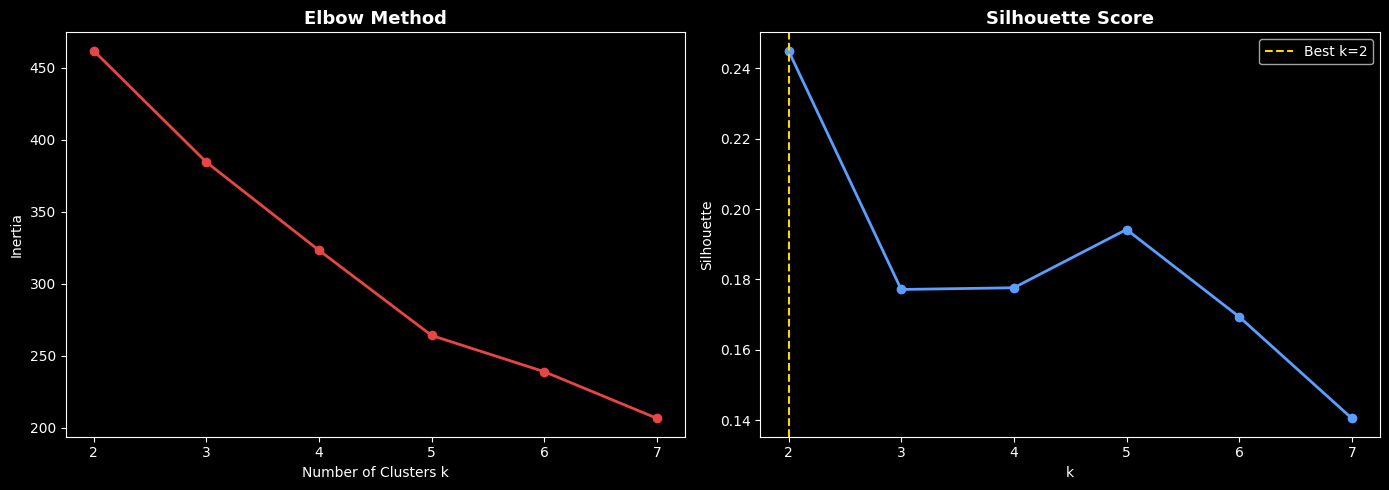

Best k by silhouette: 2


In [12]:
# Build area feature matrix: crime type mix + temporal pattern
if 'crime_category' in df.columns:
    cat_pivot  = df.groupby(['area','crime_category']).size().unstack(fill_value=0)
    cat_pivot  = cat_pivot.div(cat_pivot.sum(axis=1), axis=0)
    hour_pivot = df.groupby(['area','hour']).size().unstack(fill_value=0)
    hour_pivot = hour_pivot.div(hour_pivot.sum(axis=1), axis=0)

    feat_matrix = pd.concat([cat_pivot, hour_pivot], axis=1).fillna(0)
    feat_matrix.columns = feat_matrix.columns.astype(str)

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(feat_matrix)

    # Elbow + silhouette to find best k
    inertias, silhouettes = [], []
    K_range = range(2, 8)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        lbl = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, lbl))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(list(K_range), inertias, 'o-', color='#E84545', linewidth=2)
    axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Number of Clusters k'); axes[0].set_ylabel('Inertia')

    axes[1].plot(list(K_range), silhouettes, 'o-', color='#5C9EFF', linewidth=2)
    best_k = list(K_range)[np.argmax(silhouettes)]
    axes[1].axvline(best_k, color='gold', linestyle='--', label=f'Best k={best_k}')
    axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].legend()

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'cluster_selection.png', dpi=150)
    plt.show()
    print(f'Best k by silhouette: {best_k}')

Cluster distribution:
{0: 13, 1: 8}
Silhouette score: 0.245


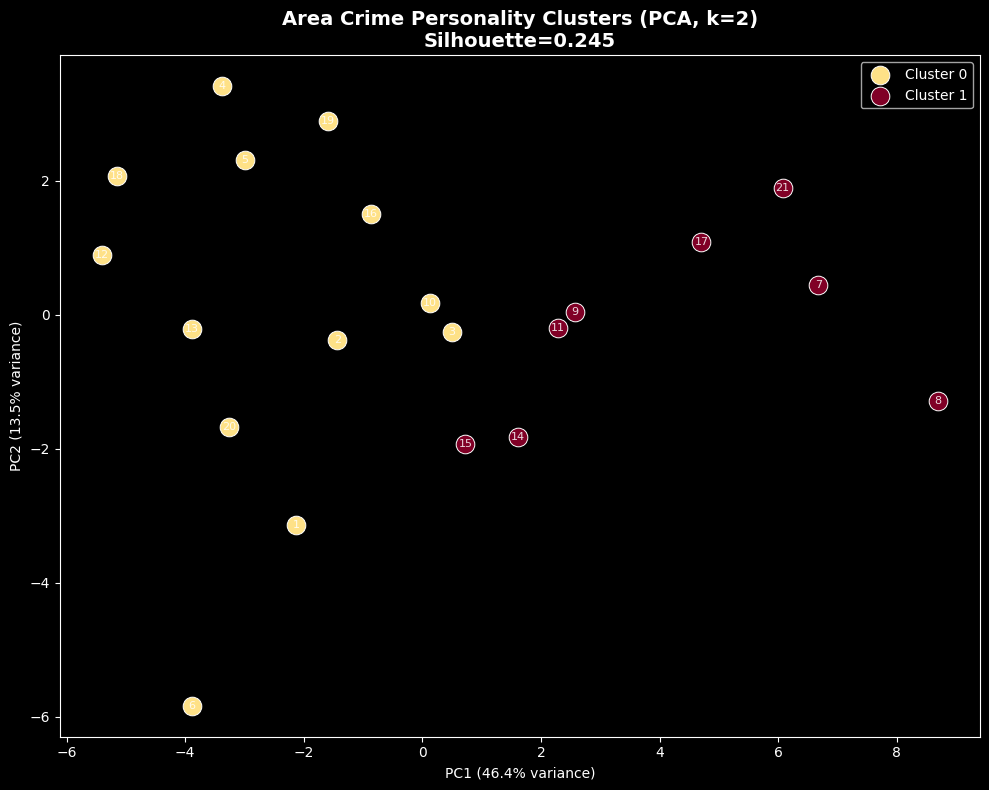

In [13]:
# Fit final KMeans with best k
N_CLUSTERS = best_k
km_final   = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(X_scaled)

cluster_df = pd.DataFrame({'area': feat_matrix.index, 'cluster': cluster_labels})
cluster_df.to_parquet(DATA_DIR / 'area_clusters.parquet', index=False)

print(f'Cluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index().to_dict()}')
print(f'Silhouette score: {silhouette_score(X_scaled, cluster_labels):.3f}')

# PCA visualisation
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.YlOrRd(np.linspace(0.2, 1.0, N_CLUSTERS))
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[colors[c]], s=180,
               label=f'Cluster {c}', edgecolors='white', linewidth=0.7, zorder=3)
for i, area in enumerate(feat_matrix.index):
    ax.annotate(str(int(area)), (X_2d[i, 0], X_2d[i, 1]), fontsize=8,
                color='white', alpha=0.85, ha='center', va='center')

ax.set_title(f'Area Crime Personality Clusters (PCA, k={N_CLUSTERS})\n'
             f'Silhouette={silhouette_score(X_scaled, cluster_labels):.3f}',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'area_clusters_pca.png', dpi=150)
plt.show()

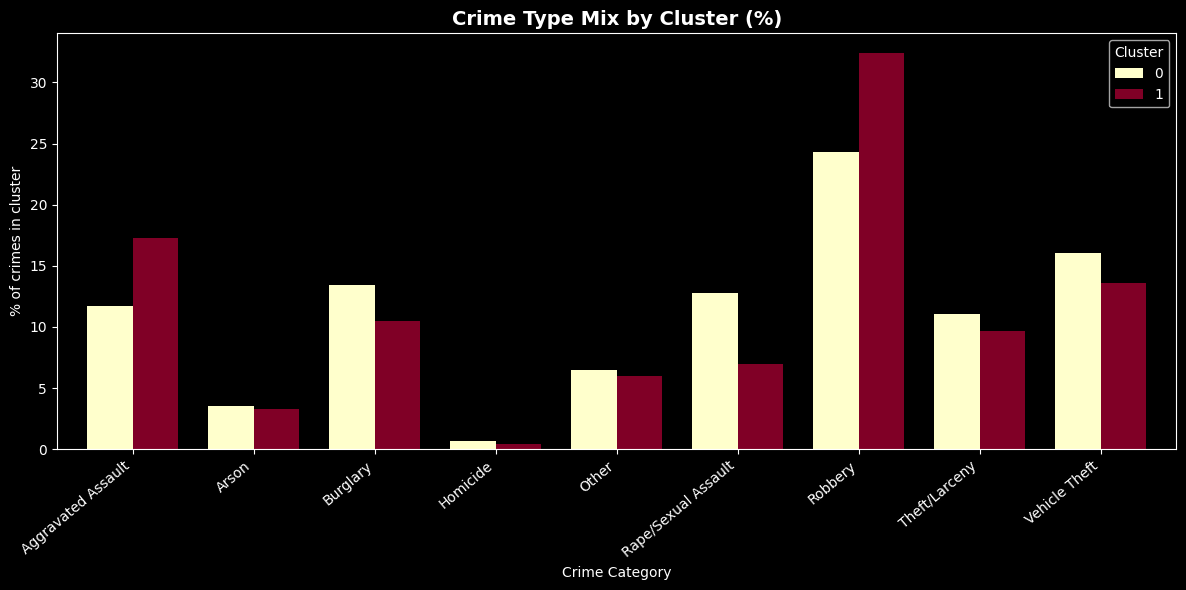

In [14]:
# Cluster profiles — what characterises each cluster?
cluster_profile = feat_matrix.copy()
cluster_profile['cluster'] = cluster_labels

# Show crime category mix per cluster
cat_cols = [c for c in cat_pivot.columns.astype(str) if c in cluster_profile.columns]
if cat_cols:
    profile_mean = cluster_profile.groupby('cluster')[cat_cols].mean() * 100
    fig, ax = plt.subplots(figsize=(12, 6))
    profile_mean.T.plot(kind='bar', ax=ax, colormap='YlOrRd', width=0.75, edgecolor='none')
    ax.set_title('Crime Type Mix by Cluster (%)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Crime Category'); ax.set_ylabel('% of crimes in cluster')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
    ax.legend(title='Cluster', loc='upper right')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'cluster_profiles.png', dpi=150)
    plt.show()

## 6️⃣ Additional Trend Plots

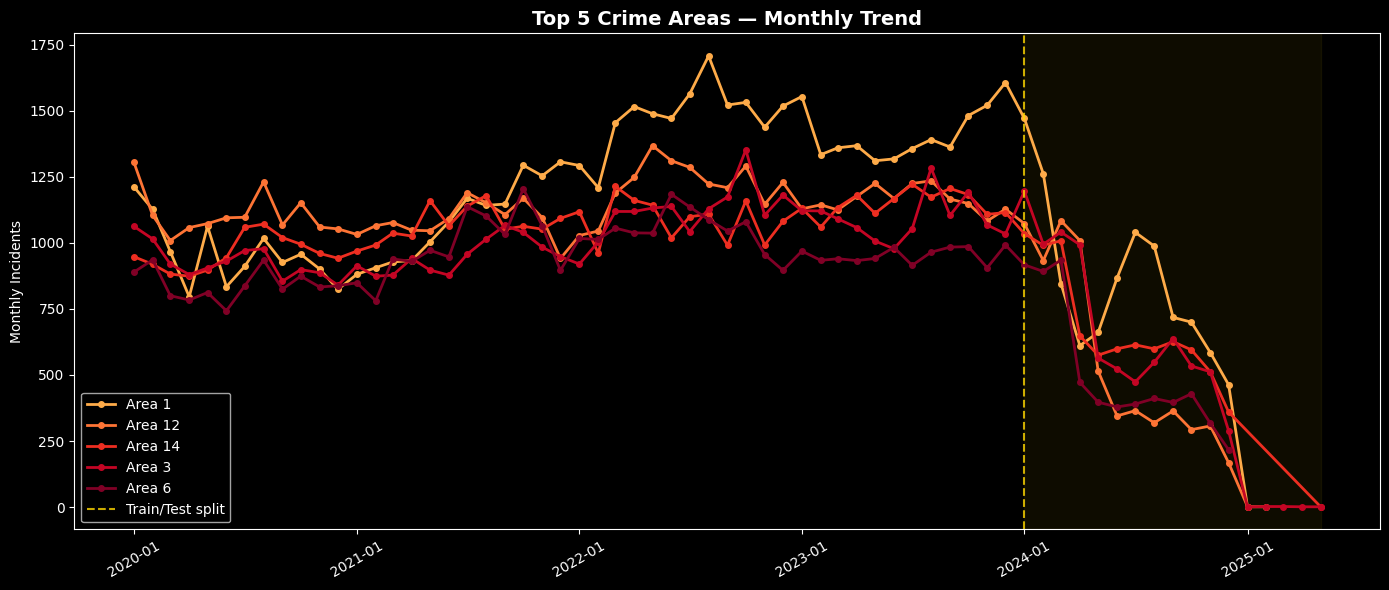

In [15]:
# Top 5 areas trend + test period
fig, ax = plt.subplots(figsize=(14, 6))
top5 = df.groupby('area').size().nlargest(5).index
palette = plt.cm.YlOrRd(np.linspace(0.4, 1.0, 5))

for i, area in enumerate(top5):
    a_ts = ts[ts['area'] == area]
    ax.plot(a_ts['ds'], a_ts['y'], 'o-', color=palette[i],
            linewidth=2, markersize=4, label=f'Area {int(area)}')

ax.axvline(cutoff_date, color='gold', linestyle='--', alpha=0.8, label='Train/Test split')
ax.axvspan(cutoff_date, ts['ds'].max(), alpha=0.06, color='gold')
ax.set_title('Top 5 Crime Areas — Monthly Trend', fontsize=14, fontweight='bold')
ax.set_ylabel('Monthly Incidents'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top5_area_trends.png', dpi=150)
plt.show()

In [16]:
print('='*55)
print('  TRENDS NOTEBOOK COMPLETE')
print('='*55)
print(f'  Outputs saved to: {OUTPUT_DIR}')
print(f'  Files generated:')
for f in sorted(OUTPUT_DIR.glob('*.png')):
    print(f'    {f.name}')
for f in sorted(OUTPUT_DIR.glob('*.csv')):
    print(f'    {f.name}')

  TRENDS NOTEBOOK COMPLETE
  Outputs saved to: D:\Coding Stuff\pps5\outputs
  Files generated:
    area_clusters_pca.png
    area_forecast_examples.png
    cluster_profiles.png
    cluster_selection.png
    confusion_matrix_oof.png
    confusion_matrix_test.png
    crime_by_area.png
    crime_by_hour.png
    crime_by_month.png
    crime_category_dist.png
    crime_composition_seasonality.png
    cv_metrics_crime_type.png
    cv_metrics_hotspot.png
    feature_importance_hotspot.png
    global_trend_forecast.png
    heatmap_hour_dow.png
    oof_diagnostics_hotspot.png
    per_class_f1.png
    shap_beeswarm_hotspot.png
    shap_crime_type.png
    shap_summary_hotspot.png
    test_evaluation_hotspot.png
    top20_crimes.png
    top5_area_trends.png
    train_test_split.png
    victim_age_clean.png
    victim_age_crime_heatmap.png
    victim_descent.png
    victim_sex.png
    victim_sex_by_crime.png
    victim_sex_descent.png
    victim_sex_hourly.png
    yearly_trend.png
    yoy_trends.pn